All dependencies

In [2]:
import subprocess
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Generate RK4 dataset (Lorentz)


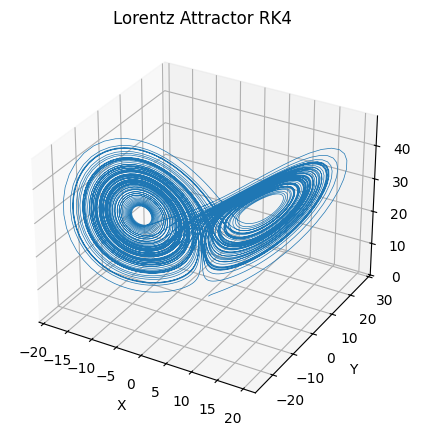

In [3]:
def generate_lorentz_data(initial):

  # Lorentz parameters
  sigma = 10
  rho = 28
  beta = 8/3

  # Lorentz system
  def lorentz(x, y, z):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

  # RK4 step
  def rk4_step(state, dt):

    k1 = lorentz(state[0], state[1], state[2])

    k2x = state[0] + dt * (k1[0] / 2)
    k2y = state[1] + dt * (k1[1] / 2)
    k2z = state[2] + dt * (k1[2] / 2)
    k2 = lorentz(k2x, k2y, k2z)

    k3x = state[0] + dt * (k2[0] / 2)
    k3y = state[1] + dt * (k2[1] / 2)
    k3z = state[2] + dt * (k2[2] / 2)
    k3 = lorentz(k3x, k3y, k3z)

    k4x = state[0] + dt * k3[0]
    k4y = state[1] + dt * k3[1]
    k4z = state[2] + dt * k3[2]
    k4 = lorentz(k4x, k4y, k4z)

    new_state = []
    new_state.append(state[0] + (dt / 6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0]))
    new_state.append(state[1] + (dt / 6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1]))
    new_state.append(state[2] + (dt / 6) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2]))

    return new_state

  # Simulation parameters
  dt = 0.01
  steps = 10000

  # Initial condition
  state = initial

  trajectory = np.zeros((steps, 3))
  trajectory[0] = state

  for i in range(1,steps):
    state = rk4_step(state, dt)
    trajectory[i] = state

  return trajectory


# Plot function
def plot_data(trajectory,title='RK4'):

  fig = plt.figure(figsize=(7, 5))
  ax = fig.add_subplot(111, projection='3d')

  ax.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2], lw=0.5)

  ax.set_xlabel("X")
  ax.set_ylabel("Y")
  ax.set_zlabel("Z")
  ax.set_title("Lorentz Attractor "+title)

  plt.show()

pt = [1.0, 1.0, 1.0]

dataset = generate_lorentz_data(pt)

plot_data(dataset)

Test data

In [13]:
X_test = dataset[:-1]
y_test = dataset[1:]

data_min = np.array([-22.32385001, -30.36881973, 1.15408467])
data_max = np.array([23.46604881, 32.62016776, 57.40074491])
data_range = data_max - data_min

def MinMaxScaling(data, min_data = data_min, range = data_range):
  scaled_data = (data - min_data) / range
  return scaled_data        

def MinMaxRescaling(scaled_data, min_data = data_min, range = data_range):
  scaled_data = np.asarray(scaled_data)
  rescaled_data = scaled_data * range + min_data
  return rescaled_data

Call Verilog testbench to get data

In [15]:
path = "E:\\Python n Verilog\\Lorentz 2 and Encryption\\Lorentz Verilog code"
os.chdir(path)

subprocess.run(["iverilog","-o","Lorentz_TB","Lorentz.v","Lorentz_tb.v"])

SCALE = 1 << 20

def to_q4_20(x):
    x = np.asarray(x)
    return np.round(x * SCALE).astype(np.int32)

data = {}
X_test_Scaled = MinMaxScaling(X_test)

X = []
Y = []
Z = []

for i in range(len(y_test)):

    # Get test input
    x_val = to_q4_20(X_test_Scaled[i][0])
    y_val = to_q4_20(X_test_Scaled[i][1])
    z_val = to_q4_20(X_test_Scaled[i][2])


    # Each plusarg is a separate list element
    plusargs = [f"+x={x_val}", f"+y={y_val}", f"+z={z_val}"]

    # Run simulation
    result = subprocess.run(["vvp","Lorentz_TB"] + plusargs, capture_output=True, text=True)
    output = result.stdout


    pattern_x = re.compile(r"\s*x\s*=\s*(-?\d+)")
    pattern_y = re.compile(r"\s*y\s*=\s*(-?\d+)")
    pattern_z = re.compile(r"\s*z\s*=\s*(-?\d+)")

    for line in output.splitlines():
        match1 = pattern_x.match(line)
        match2 = pattern_y.match(line)
        match3 = pattern_z.match(line)

        if match1:
            X.append(int(match1.group(1)) / SCALE)

        if match2:
            Y.append(int(match2.group(1)) / SCALE)

        if match3:
            Z.append(int(match3.group(1)) / SCALE)

X_Rescaled = MinMaxRescaling(X,min_data= data_min[0], range = data_range[0])
Y_Rescaled = MinMaxRescaling(Y,min_data= data_min[1], range = data_range[1])
Z_Rescaled = MinMaxRescaling(Z,min_data= data_min[2], range = data_range[2])

data['X_value'] = X_Rescaled
data['Y_value'] = Y_Rescaled
data['Z_value'] = Z_Rescaled

data_df = pd.DataFrame.from_dict(data, orient="columns")
data_df.index += 1

data_df.to_csv("Lorentz_Data.csv")

Plot Data

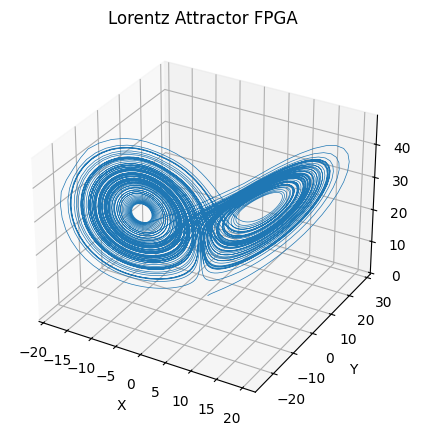

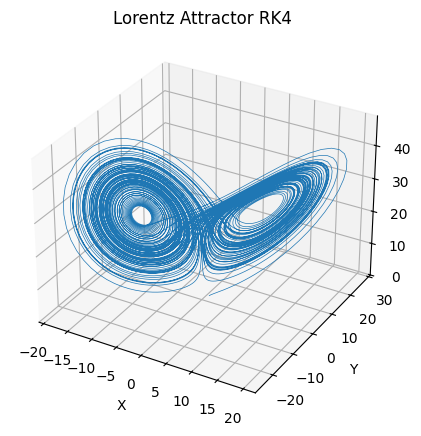

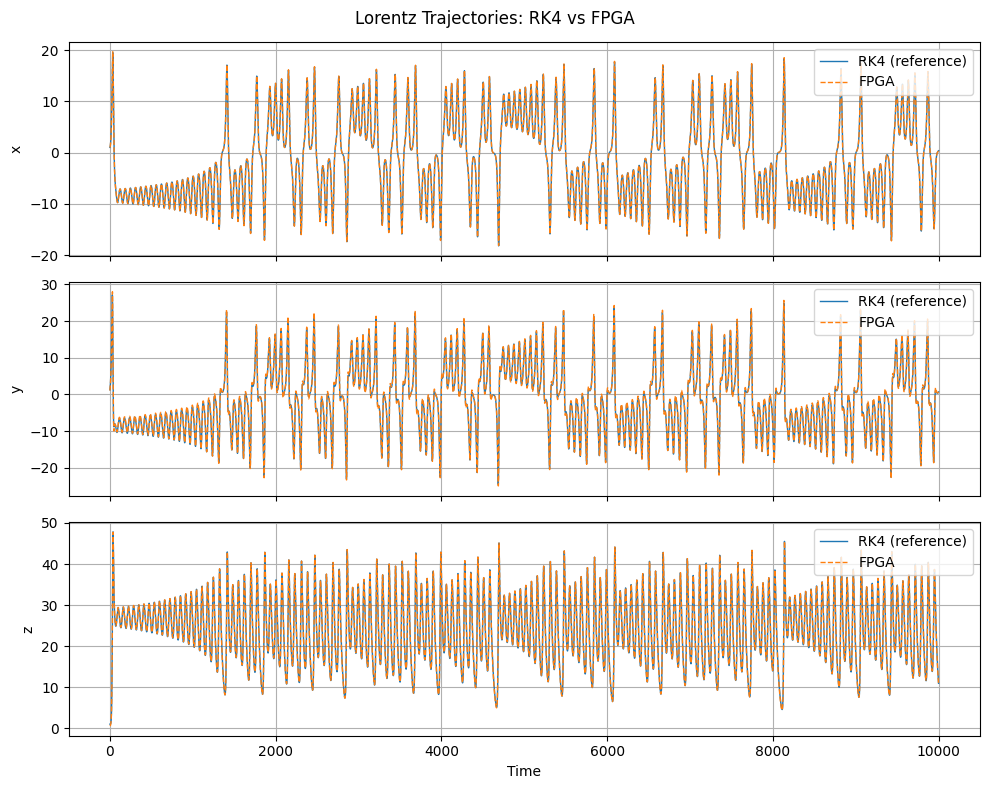

In [16]:
dataset_fpga = np.column_stack((X_Rescaled, Y_Rescaled, Z_Rescaled))

# Plot function
def plot_data(trajectory,title='RK4'):

  fig = plt.figure(figsize=(7, 5))
  ax = fig.add_subplot(111, projection='3d')

  ax.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2], lw=0.5)

  ax.set_xlabel("X")
  ax.set_ylabel("Y")
  ax.set_zlabel("Z")
  ax.set_title("Lorentz Attractor "+title)

  plt.show()

plot_data(dataset_fpga,'FPGA')
plot_data(y_test)

def compare_trajectories(y_pred,new_y):

  x = new_y[:,0]
  y = new_y[:,1]
  z = new_y[:,2]

  x_model = y_pred[:,0]
  y_model = y_pred[:,1]
  z_model = y_pred[:,2]

  t = [i for i in range(len(x))]

  fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

  plt.subplot(3,1,1)
  plt.plot(t, x, label='RK4 (reference)', linewidth=1)
  plt.plot(t, x_model, linestyle='--', label='FPGA', linewidth=1)
  plt.ylabel('x')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,2)
  plt.plot(t, y, label='RK4 (reference)', linewidth=1)
  plt.plot(t, y_model, linestyle='--', label='FPGA', linewidth=1)
  plt.ylabel('y')
  plt.grid(True)
  plt.legend(loc='upper right')

  plt.subplot(3,1,3)
  plt.plot(t, z, label='RK4 (reference)', linewidth=1)
  plt.plot(t, z_model, linestyle='--', label='FPGA', linewidth=1)
  plt.ylabel('z')
  plt.grid(True)
  plt.legend(loc='upper right')

  axs[-1].set_xlabel('Time')
  fig.suptitle('Lorentz Trajectories: RK4 vs FPGA')
  plt.tight_layout()
  plt.show()

compare_trajectories(dataset_fpga,y_test)